In [1]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [2]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.9 MB/s eta 0:00:00


In [3]:
!pip install  rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=5459f354ee971c8dd77b397d2012750915ff09903ec4c8f3ff21fdc69b26f4ba
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [4]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
from datasets import Dataset
import evaluate
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

✓ GPU cache cleared


# STEP 1: LOAD THE SPLIT DATASETS (REDUCED SIZE)


In [6]:
import zipfile
from sklearn.model_selection import train_test_split
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Extract the zip file if needed
zip_path = "fr-tr.txt.zip"
extract_dir = "dataset"

if not os.path.exists(extract_dir):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print(f"Dataset directory '{extract_dir}' already exists.")

# Find the data files in the extracted directory
print("\nLooking for data files...")
data_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        full_path = os.path.join(root, file)
        data_files.append(full_path)
        print(f"Found: {full_path}")

# Load the parallel corpus files
# Look for files ending with .fr and .tr
french_file = None
turkish_file = None

for file in data_files:
    if file.endswith('.fr') or file.endswith('.FR'):
        french_file = file
        print(f"\n✓ French file identified: {file}")
    elif file.endswith('.tr') or file.endswith('.TR'):
        turkish_file = file
        print(f"✓ Turkish file identified: {file}")

# If still not found, look for files with language codes in the name
if not french_file or not turkish_file:
    print("\nSearching by filename pattern...")
    for file in data_files:
        filename = os.path.basename(file).lower()
        if 'fr-tr.fr' in filename or 'fr.tr.fr' in filename:
            french_file = file
            print(f"✓ French file found: {file}")
        elif 'fr-tr.tr' in filename or 'fr.tr.tr' in filename:
            turkish_file = file
            print(f"✓ Turkish file found: {file}")

if not french_file or not turkish_file:
    raise FileNotFoundError(
        f"Could not find parallel corpus files!\n"
        f"French file: {french_file}\n"
        f"Turkish file: {turkish_file}\n"
        f"Available files: {data_files}"
    )

# Load the data
print(f"\nLoading French sentences from: {french_file}")
with open(french_file, 'r', encoding='utf-8') as f:
    french_sentences = [line.strip() for line in f if line.strip()]

print(f"Loading Turkish sentences from: {turkish_file}")
with open(turkish_file, 'r', encoding='utf-8') as f:
    turkish_sentences = [line.strip() for line in f if line.strip()]

# Create a DataFrame
print(f"\nTotal French sentences: {len(french_sentences)}")
print(f"Total Turkish sentences: {len(turkish_sentences)}")

# Make sure both have the same length
min_len = min(len(french_sentences), len(turkish_sentences))
combined_df = pd.DataFrame({
    'french': french_sentences[:min_len],
    'turkish': turkish_sentences[:min_len]
})

print(f"\nCombined dataset size: {len(combined_df)}")

# Custom split: 80% train, 10% validation, 10% test
# (You can adjust these ratios)
print("\nCreating custom train/val/test split (80/10/10)...")
train_custom, temp = train_test_split(combined_df, test_size=0.2, random_state=42)
val_custom, test_custom = train_test_split(temp, test_size=0.5, random_state=42)

print(f"\nCustom split sizes:")
print(f"Train: {len(train_custom)}")
print(f"Validation: {len(val_custom)}")
print(f"Test: {len(test_custom)}")

# Save the splits
print("\nSaving data splits...")
os.makedirs('data', exist_ok=True)
train_custom.to_csv('data/train.csv', index=False)
val_custom.to_csv('data/val.csv', index=False)
test_custom.to_csv('data/test.csv', index=False)

print("Data saved to 'data/' directory")

Extracting fr-tr.txt.zip...
Extraction complete!

Looking for data files...
Found: dataset/TED2020.fr-tr.fr
Found: dataset/TED2020.fr-tr.tr
Found: dataset/LICENSE
Found: dataset/README
Found: dataset/TED2020.fr-tr.xml

✓ French file identified: dataset/TED2020.fr-tr.fr
✓ Turkish file identified: dataset/TED2020.fr-tr.tr

Loading French sentences from: dataset/TED2020.fr-tr.fr
Loading Turkish sentences from: dataset/TED2020.fr-tr.tr

Total French sentences: 368006
Total Turkish sentences: 368006

Combined dataset size: 368006

Creating custom train/val/test split (80/10/10)...

Custom split sizes:
Train: 294404
Validation: 36801
Test: 36801

Saving data splits...
Data saved to 'data/' directory


In [7]:
print("STEP 1: LOADING DATASETS (REDUCED SIZE FOR FASTER TRAINING)")
print("="*60)

# Load full datasets
train_df = pd.read_csv('data/train.csv')
train_df = train_df.sample(frac=0.4, random_state=42)
val_df = pd.read_csv('data/val.csv')
val_df = val_df.sample(frac=0.5, random_state=42)
test_df = pd.read_csv('data/test.csv')
test_df = test_df.sample(frac=0.5, random_state=42)

print(f"Original train set: {len(train_df)} samples")
print(f"Original validation set: {len(val_df)} samples")
print(f"Original test set: {len(test_df)} samples")

# # Reduce dataset sizes for faster training
# # Train: 1/4 of original, Val: 1/4 of original, Test: 1/2 of original
# train_df = train_df_full.sample(n=len(train_df_full)//4, random_state=42).reset_index(drop=True)
# val_df = val_df_full.sample(n=len(val_df_full)//4, random_state=42).reset_index(drop=True)
# test_df = test_df_full.sample(n=len(test_df_full)//2, random_state=42).reset_index(drop=True)



# Show sample
print("\nSample from test set:")
for i in range(5):
    print(f"\n[{i+1}]")
    print(f"French: {test_df.iloc[i]['french']}")
    print(f"Turkish: {test_df.iloc[i]['turkish']}")

STEP 1: LOADING DATASETS (REDUCED SIZE FOR FASTER TRAINING)
Original train set: 117762 samples
Original validation set: 18400 samples
Original test set: 18400 samples

Sample from test set:

[1]
French: Ceci va à l'encontre de la sagesse populaire qui veut que nous racontions nos buts à nos amis, non?
Turkish: Yani bu olay hedeflerimizi arkadaşlarımıza söylememiz gerektiğini söyleyen sağduyuya aykırı değil mi?

[2]
French: Mais ce sont des exemples réels dans l'urbanisation et dans le changement qui s'est produit ces dernières années, et la sensibilité grandissante à l'importance à l'importance de nos environnements urbains en tant que centres culturels.
Turkish: Ama bunlar şehirleşmenin gerçek örnekleri ve değişim son birkaç yıl içinde gerçekleşti ve şehir alanlarına kültürel merkezler olarak verilmesi gereken önemle ilgili duyarlılık arttı.

[3]
French: Et nous avons une école. C'est notre -- ces deux dernières années, nous avons ouvert une école élémentaire où nous avons 850 enfants

In [8]:
# Check for null values in full datasets
print("\nChecking for null/empty values in full datasets:")
print(f"Train nulls: French={train_df['french'].isnull().sum()}, Turkish={train_df['turkish'].isnull().sum()}")
print(f"Val nulls: French={val_df['french'].isnull().sum()}, Turkish={val_df['turkish'].isnull().sum()}")
print(f"Test nulls: French={test_df['french'].isnull().sum()}, Turkish={test_df['turkish'].isnull().sum()}")

# Remove any null values before sampling
train_df = train_df.dropna(subset=['french', 'turkish']).reset_index(drop=True)
val_df = val_df.dropna(subset=['french', 'turkish']).reset_index(drop=True)
test_df = test_df.dropna(subset=['french', 'turkish']).reset_index(drop=True)

# Ensure all values are strings
train_df['french'] = train_df['french'].astype(str)
train_df['turkish'] = train_df['turkish'].astype(str)
val_df['french'] = val_df['french'].astype(str)
val_df['turkish'] = val_df['turkish'].astype(str)
test_df['french'] = test_df['french'].astype(str)
test_df['turkish'] = test_df['turkish'].astype(str)


Checking for null/empty values in full datasets:
Train nulls: French=0, Turkish=0
Val nulls: French=0, Turkish=0
Test nulls: French=0, Turkish=0


# STEP 2: LOAD PRE-TRAINED NLLB MODEL

In [9]:
print("STEP 2: LOADING PRE-TRAINED NLLB MODEL")
print("="*60)

# NLLB model - optimized for low-resource languages
model_name = "facebook/nllb-200-distilled-600M"
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="fra_Latn", tgt_lang="tur_Latn")
pretrained_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# NLLB uses specific language codes
# French: fra_Latn, Turkish: tur_Latn
src_lang = "fra_Latn"
tgt_lang = "tur_Latn"

print("✓ Model and tokenizer loaded successfully!")
print(f"✓ Source language: {src_lang}")
print(f"✓ Target language: {tgt_lang}")

# Get the language token IDs using the correct method for NLLB
try:
    # Method 1: Try using the tokenizer's language code to ID mapping
    if hasattr(tokenizer, 'lang_code_to_id'):
        src_lang_id = tokenizer.lang_code_to_id[src_lang]
        tgt_lang_id = tokenizer.lang_code_to_id[tgt_lang]
    else:
        # Method 2: Convert language codes to token IDs directly
        src_lang_id = tokenizer.convert_tokens_to_ids(src_lang)
        tgt_lang_id = tokenizer.convert_tokens_to_ids(tgt_lang)

    print(f"✓ Source language ID: {src_lang_id}")
    print(f"✓ Target language ID: {tgt_lang_id}")
except Exception as e:
    print(f"Warning: Could not get language IDs using standard method: {e}")
    # Method 3: Get from special tokens
    # For NLLB, language tokens are in the vocabulary
    src_lang_id = tokenizer.vocab.get(src_lang, None)
    tgt_lang_id = tokenizer.vocab.get(tgt_lang, None)

    if src_lang_id is None or tgt_lang_id is None:
        # Method 4: Encode the language code and get the first token
        src_lang_id = tokenizer.encode(src_lang, add_special_tokens=False)[0]
        tgt_lang_id = tokenizer.encode(tgt_lang, add_special_tokens=False)[0]

    print(f"✓ Source language ID (fallback): {src_lang_id}")
    print(f"✓ Target language ID (fallback): {tgt_lang_id}")


STEP 2: LOADING PRE-TRAINED NLLB MODEL
Loading model: facebook/nllb-200-distilled-600M


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✓ Model and tokenizer loaded successfully!
✓ Source language: fra_Latn
✓ Target language: tur_Latn
✓ Source language ID: 256057
✓ Target language ID: 256184


# STEP 3: TEST PRE-TRAINED MODEL

In [10]:

print("STEP 3: TESTING PRE-TRAINED MODEL ON TEST SET")
print("="*60)

def translate_batch(texts, model, tokenizer, tgt_lang, batch_size=16):
    """Translate a list of texts in batches with specified target language"""
    translations = []

    # Get the target language token id
    forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang)

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i:i+batch_size]

        # Tokenize with source language set
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate translations with forced target language
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        # Decode
        batch_translations = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(batch_translations)

    return translations

# ✅ Test only on the first 100 samples
test_subset = test_df.head(100).copy()
print(f"\nTesting on {len(test_subset)} samples...")

pretrained_translations = translate_batch(
    test_subset['french'].tolist(),
    pretrained_model,
    tokenizer,
    tgt_lang=tgt_lang,
    batch_size=16
)

test_subset['pretrained_translation'] = pretrained_translations

# Show some examples
print("\n" + "="*60)
print("TRANSLATION EXAMPLES (PRE-TRAINED MODEL)")
print("="*60)
for i in range(5):
    print(f"\n[Example {i+1}]")
    print(f"Source (FR):     {test_subset.iloc[i]['french']}")
    print(f"Reference (TR):  {test_subset.iloc[i]['turkish']}")
    print(f"Predicted (TR):  {test_subset.iloc[i]['pretrained_translation']}")


STEP 3: TESTING PRE-TRAINED MODEL ON TEST SET

Testing on 100 samples...


Translating: 100%|██████████| 7/7 [00:26<00:00,  3.82s/it]


TRANSLATION EXAMPLES (PRE-TRAINED MODEL)

[Example 1]
Source (FR):     Ceci va à l'encontre de la sagesse populaire qui veut que nous racontions nos buts à nos amis, non?
Reference (TR):  Yani bu olay hedeflerimizi arkadaşlarımıza söylememiz gerektiğini söyleyen sağduyuya aykırı değil mi?
Predicted (TR):  Bu, hedeflerimizi arkadaşlarımıza anlatmamızı isteyen popüler bilgeliğe aykırı değil mi?

[Example 2]
Source (FR):     Mais ce sont des exemples réels dans l'urbanisation et dans le changement qui s'est produit ces dernières années, et la sensibilité grandissante à l'importance à l'importance de nos environnements urbains en tant que centres culturels.
Reference (TR):  Ama bunlar şehirleşmenin gerçek örnekleri ve değişim son birkaç yıl içinde gerçekleşti ve şehir alanlarına kültürel merkezler olarak verilmesi gereken önemle ilgili duyarlılık arttı.
Predicted (TR):  Fakat bunlar son yıllarda meydana gelen kentleşme ve değişimlerin gerçek örnekleridir ve kültürel merkezler olarak kent 

# STEP 4: EVALUATE PRE-TRAINED MODEL

In [11]:
print("STEP 4: EVALUATING PRE-TRAINED MODEL")
print("="*60)

# Load evaluation metrics
bleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
rouge_metric = evaluate.load("rouge")
chrf_metric = evaluate.load("chrf")

# Prepare predictions and references
predictions = test_subset['pretrained_translation'].tolist()
references = test_subset['turkish'].tolist()

# Calculate all metrics
pretrained_bleu = bleu_metric.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

pretrained_meteor = meteor_metric.compute(
    predictions=predictions,
    references=references
)

pretrained_rouge = rouge_metric.compute(
    predictions=predictions,
    references=references
)

pretrained_chrf = chrf_metric.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

print("\n" + "="*50)
print("PRE-TRAINED MODEL EVALUATION SCORES")
print("="*50)
print(f"BLEU Score:      {pretrained_bleu['score']:.2f}")
print(f"METEOR Score:    {pretrained_meteor['meteor']:.4f}")
print(f"chrF Score:      {pretrained_chrf['score']:.2f}")
print(f"ROUGE-1:         {pretrained_rouge['rouge1']:.4f}")
print(f"ROUGE-2:         {pretrained_rouge['rouge2']:.4f}")
print(f"ROUGE-L:         {pretrained_rouge['rougeL']:.4f}")
print("="*50)

STEP 4: EVALUATING PRE-TRAINED MODEL


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



PRE-TRAINED MODEL EVALUATION SCORES
BLEU Score:      10.66
METEOR Score:    0.3463
chrF Score:      43.53
ROUGE-1:         0.4339
ROUGE-2:         0.2434
ROUGE-L:         0.3991


# STEP 5: PREPARE DATA FOR FINE-TUNING

In [12]:
print("STEP 5: PREPARING DATA FOR FINE-TUNING")
print("="*60)

# Debug: Check for null values
print("\nChecking for null values in train data:")
print(train_df.isnull().sum())
print("\nChecking for null values in validation data:")
print(val_df.isnull().sum())

# Remove any rows with null values
print("\nRemoving rows with null values...")
train_df_clean = train_df.dropna(subset=['french', 'turkish']).reset_index(drop=True)
val_df_clean = val_df.dropna(subset=['french', 'turkish']).reset_index(drop=True)

print(f"After cleaning - Train: {len(train_df_clean)} samples (removed {len(train_df) - len(train_df_clean)})")
print(f"After cleaning - Val: {len(val_df_clean)} samples (removed {len(val_df) - len(val_df_clean)})")

# Ensure all values are strings
train_df_clean['french'] = train_df_clean['french'].astype(str)
train_df_clean['turkish'] = train_df_clean['turkish'].astype(str)
val_df_clean['french'] = val_df_clean['french'].astype(str)
val_df_clean['turkish'] = val_df_clean['turkish'].astype(str)

# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df_clean[['french', 'turkish']])
val_dataset = Dataset.from_pandas(val_df_clean[['french', 'turkish']])

print(f"\nTrain dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")

# Debug: Check target language
print(f"\nTarget language code: {tgt_lang}")
print(f"Source language code: {src_lang}")

# Get target language token id for labels
forced_bos_token_id = tgt_lang_id
print(f"Forced BOS token ID: {forced_bos_token_id}")

# Preprocessing function for NLLB - SIMPLIFIED VERSION
def preprocess_function(examples):
    # The examples come as a dict with lists
    inputs = examples['french']
    targets = examples['turkish']

    # Convert to list if needed
    if not isinstance(inputs, list):
        inputs = [inputs]
    if not isinstance(targets, list):
        targets = [targets]

    # Convert all to strings and filter empty
    inputs = [str(x).strip() for x in inputs if x is not None and str(x).strip()]
    targets = [str(x).strip() for x in targets if x is not None and str(x).strip()]

    # Ensure same length
    min_len = min(len(inputs), len(targets))
    inputs = inputs[:min_len]
    targets = targets[:min_len]

    if not inputs or not targets:
        return {"input_ids": [], "attention_mask": [], "labels": []}

    # Tokenize inputs (source language is already set in tokenizer)
    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding=False,
        return_tensors=None  # Return lists, not tensors
    )

    # Tokenize targets - use the tokenizer directly with target language
    # For NLLB, we need to set the target language differently
    labels = tokenizer(
        targets,
        max_length=128,
        truncation=True,
        padding=False,
        return_tensors=None
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply preprocessing
print("\nTokenizing datasets...")
print("This may take a few minutes...")

# First, let's test with a small batch
print("\nTesting preprocessing with first 5 examples...")
test_batch = {
    'french': train_dataset['french'][:5],
    'turkish': train_dataset['turkish'][:5]
}
print(f"Test batch French type: {type(test_batch['french'])}")
print(f"Test batch French[0]: {test_batch['french'][0]}")

try:
    test_result = preprocess_function(test_batch)
    print(f"✓ Test preprocessing successful! Got {len(test_result['input_ids'])} examples")
except Exception as e:
    print(f"✗ Test preprocessing failed: {e}")
    import traceback
    traceback.print_exc()
    raise

# If test passed, proceed with full dataset
try:
    tokenized_train = train_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=train_dataset.column_names,
        desc="Tokenizing train set",
        batch_size=1000  # Process 1000 examples at a time
    )
    print(f"✓ Train set tokenized: {len(tokenized_train)} examples")

    tokenized_val = val_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=val_dataset.column_names,
        desc="Tokenizing validation set",
        batch_size=1000
    )
    print(f"✓ Validation set tokenized: {len(tokenized_val)} examples")
    print("✓ All datasets tokenized successfully!")

except Exception as e:
    print(f"ERROR during tokenization: {e}")
    print("\nDebugging information:")
    print(f"Train dataset columns: {train_dataset.column_names}")
    print(f"Train dataset features: {train_dataset.features}")
    print("\nFirst train example:")
    print(train_dataset[0])
    import traceback
    traceback.print_exc()
    raise

STEP 5: PREPARING DATA FOR FINE-TUNING

Checking for null values in train data:
french     0
turkish    0
dtype: int64

Checking for null values in validation data:
french     0
turkish    0
dtype: int64

Removing rows with null values...
After cleaning - Train: 117762 samples (removed 0)
After cleaning - Val: 18400 samples (removed 0)

Train dataset: 117762 samples
Validation dataset: 18400 samples

Target language code: tur_Latn
Source language code: fra_Latn
Forced BOS token ID: 256184

Tokenizing datasets...
This may take a few minutes...

Testing preprocessing with first 5 examples...
Test batch French type: <class 'list'>
Test batch French[0]: Deux, ça vous permettra d'être payé et promu très tôt dans votre carrière et très tôt dans n'importe quel domaine.
✓ Test preprocessing successful! Got 5 examples


Tokenizing train set:   0%|          | 0/117762 [00:00<?, ? examples/s]

✓ Train set tokenized: 117762 examples


Tokenizing validation set:   0%|          | 0/18400 [00:00<?, ? examples/s]

✓ Validation set tokenized: 18400 examples
✓ All datasets tokenized successfully!


# STEP 6: FINE-TUNE THE MODEL (OPTIMIZED FOR SPEED)

In [13]:

import evaluate

bleu_metric = evaluate.load("sacrebleu")


In [14]:
print("STEP 6: FINE-TUNING NLLB MODEL (LOW MEMORY MODE)")
print("="*60)

# Clear GPU cache before training
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

# Load fresh model for training
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# Enable gradient checkpointing to save memory
model.gradient_checkpointing_enable()
print("✓ Gradient checkpointing enabled (saves memory)")

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# LOW MEMORY Training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./m2m100-fr-tr-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    weight_decay=0.01,
    save_total_limit=2,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    generation_max_length=128,
      max_steps=5000,
)

print("\nTraining configuration (LOW MEMORY MODE):")
print(f"  - Epochs: 2")
print(f"  - Batch size per device: 2 (very small)")
print(f"  - Gradient accumulation: 8 steps (effective batch = 16)")
print(f"  - Learning rate: 3e-5")
print(f"  - FP16: {torch.cuda.is_available()}")
print(f"  - Gradient checkpointing: Enabled")
print(f"  - Estimated GPU memory: ~6-8 GB")

# Compute metrics function (simplified to save memory)
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Replace -100 in labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute BLEU
    result = bleu_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

    return {"bleu": result["score"]}

# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Set the model to use forced_bos_token_id during generation
model.config.forced_bos_token_id = tgt_lang_id

# Start training
print("\nStarting training with low memory settings...")
print("This will take longer but use much less GPU memory!\n")

try:
    train_result = trainer.train()

    print("\n✓ Training completed!")
    print(f"Training loss: {train_result.training_loss:.4f}")

    # Save the fine-tuned model
    trainer.save_model("./nllb-fr-tr-finetuned/final_model")
    tokenizer.save_pretrained("./nllb-fr-tr-finetuned/final_model")
    print("\n✓ Fine-tuned model saved!")

except RuntimeError as e:
    if "out of memory" in str(e):
        print("\n" + "="*60)
        print("STILL OUT OF MEMORY!")
        print("="*60)
        print("\nTry these options:")
        print("1. Reduce batch size to 1: per_device_train_batch_size=1")
        print("2. Increase gradient accumulation: gradient_accumulation_steps=16")
        print("3. Use a smaller model: facebook/nllb-200-distilled-600M is already small,")
        print("   but you could try the 1.3B version with CPU offloading")
        print("4. Train on CPU (very slow): device = 'cpu'")
        print("5. Use a smaller dataset (already done)")
        print(f"\nCurrent GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
        print(f"Max GPU memory allocated: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")
        raise
    else:
        raise


STEP 6: FINE-TUNING NLLB MODEL (LOW MEMORY MODE)
✓ GPU cache cleared
✓ Gradient checkpointing enabled (saves memory)

Training configuration (LOW MEMORY MODE):
  - Epochs: 2
  - Batch size per device: 2 (very small)
  - Gradient accumulation: 8 steps (effective batch = 16)
  - Learning rate: 3e-5
  - FP16: True
  - Gradient checkpointing: Enabled
  - Estimated GPU memory: ~6-8 GB

Starting training with low memory settings...
This will take longer but use much less GPU memory!



wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: slimaniaymen113 (slimaniaymen113-university-of-michigan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Bleu
0,2.084700,1.922243,11.608637


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✓ Training completed!
Training loss: 2.1017

✓ Fine-tuned model saved!


# STEP 7: TEST FINE-TUNED MODEL

In [20]:
# ============================================
# STEP 7: TESTING FINE-TUNED MODEL (ULTRA LOW MEMORY)
# ============================================
print("\n" + "="*60)
print("STEP 7: TESTING FINE-TUNED MODEL ON TEST SET")
print("="*60)

import torch
import gc

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

# Load the fine-tuned model
print("Loading fine-tuned model...")
finetuned_model = AutoModelForSeq2SeqLM.from_pretrained("./nllb-fr-tr-finetuned/final_model").to(device)
finetuned_model.config.forced_bos_token_id = forced_bos_token_id

print(f"Testing on {len(test_subset)} samples...")

# Ultra low memory translation function
def translate_batch_ultra_low_memory(texts, model, tokenizer, tgt_lang, batch_size=4):
    """Ultra low memory translation - batch size 4"""
    translations = []
    forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang)

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating (low memory)"):
        batch = texts[i:i+batch_size]

        # Clear cache periodically
        if i % 20 == 0:
            torch.cuda.empty_cache()

        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                max_length=128,
                num_beams=2,  # Reduced beams for memory
                early_stopping=True
            )

        batch_translations = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(batch_translations)

        # Clean up
        del inputs, outputs

    return translations

# Translate with fine-tuned model
finetuned_translations = translate_batch_ultra_low_memory(
    test_subset['french'].tolist(),
    finetuned_model,
    tokenizer,
    tgt_lang=tgt_lang,
    batch_size=4  # Ultra low memory
)

test_subset['finetuned_translation'] = finetuned_translations

# Show comparison examples
print("\n" + "="*60)
print("TRANSLATION COMPARISON")
print("="*60)
for i in range(5):
    print(f"\n[Example {i+1}]")
    print(f"Source (FR):        {test_subset.iloc[i]['french'][:80]}...")
    print(f"Reference (TR):     {test_subset.iloc[i]['turkish'][:80]}...")
    print(f"Pre-trained:        {test_subset.iloc[i]['pretrained_translation'][:80]}...")
    print(f"Fine-tuned:         {test_subset.iloc[i]['finetuned_translation'][:80]}...")

print("\n✓ Fine-tuned translations completed!")
print(f"GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Clear memory after testing
del finetuned_model
torch.cuda.empty_cache()
gc.collect()


STEP 7: TESTING FINE-TUNED MODEL ON TEST SET
Loading fine-tuned model...
Testing on 100 samples...


Translating (low memory): 100%|██████████| 25/25 [00:34<00:00,  1.37s/it]



TRANSLATION COMPARISON

[Example 1]
Source (FR):        Ceci va à l'encontre de la sagesse populaire qui veut que nous racontions nos bu...
Reference (TR):     Yani bu olay hedeflerimizi arkadaşlarımıza söylememiz gerektiğini söyleyen sağdu...
Pre-trained:        Bu, hedeflerimizi arkadaşlarımıza anlatmamızı isteyen popüler bilgeliğe aykırı d...
Fine-tuned:         Bu, hedeflerimizi arkadaşlarımıza anlatmamızı isteyen popüler bilgiye aykırı, de...

[Example 2]
Source (FR):        Mais ce sont des exemples réels dans l'urbanisation et dans le changement qui s'...
Reference (TR):     Ama bunlar şehirleşmenin gerçek örnekleri ve değişim son birkaç yıl içinde gerçe...
Pre-trained:        Fakat bunlar son yıllarda meydana gelen kentleşme ve değişimlerin gerçek örnekle...
Fine-tuned:         Fakat bunlar, son birkaç yılda yaşanan kentleşme ve değişimlerin ve kültürel mer...

[Example 3]
Source (FR):        Et nous avons une école. C'est notre -- ces deux dernières années, nous avons ou...
R

114

# STEP 8: EVALUATE FINE-TUNED MODEL

In [21]:
print("STEP 8: EVALUATING FINE-TUNED MODEL")
print("="*60)

# Prepare predictions and references for fine-tuned model
finetuned_predictions = test_subset['finetuned_translation'].tolist()
finetuned_references = test_subset['turkish'].tolist()

# Calculate all metrics for fine-tuned model
finetuned_bleu = bleu_metric.compute(
    predictions=finetuned_predictions,
    references=[[ref] for ref in finetuned_references]
)

finetuned_meteor = meteor_metric.compute(
    predictions=finetuned_predictions,
    references=finetuned_references
)

finetuned_rouge = rouge_metric.compute(
    predictions=finetuned_predictions,
    references=finetuned_references
)

finetuned_chrf = chrf_metric.compute(
    predictions=finetuned_predictions,
    references=[[ref] for ref in finetuned_references]
)

print("\n" + "="*50)
print("FINE-TUNED MODEL EVALUATION SCORES")
print("="*50)
print(f"BLEU Score:      {finetuned_bleu['score']:.2f}")
print(f"METEOR Score:    {finetuned_meteor['meteor']:.4f}")
print(f"chrF Score:      {finetuned_chrf['score']:.2f}")
print(f"ROUGE-1:         {finetuned_rouge['rouge1']:.4f}")
print(f"ROUGE-2:         {finetuned_rouge['rouge2']:.4f}")
print(f"ROUGE-L:         {finetuned_rouge['rougeL']:.4f}")
print("="*50)

# Show improvement comparison
print("\n" + "="*50)
print("IMPROVEMENT COMPARISON")
print("="*50)
print(f"{'Metric':<15} {'Pre-trained':<12} {'Fine-tuned':<12} {'Improvement':<12}")
print("-" * 50)
print(f"{'BLEU':<15} {pretrained_bleu['score']:<12.2f} {finetuned_bleu['score']:<12.2f} {finetuned_bleu['score'] - pretrained_bleu['score']:<12.2f}")
print(f"{'METEOR':<15} {pretrained_meteor['meteor']:<12.4f} {finetuned_meteor['meteor']:<12.4f} {finetuned_meteor['meteor'] - pretrained_meteor['meteor']:<12.4f}")
print(f"{'chrF':<15} {pretrained_chrf['score']:<12.2f} {finetuned_chrf['score']:<12.2f} {finetuned_chrf['score'] - pretrained_chrf['score']:<12.2f}")
print(f"{'ROUGE-1':<15} {pretrained_rouge['rouge1']:<12.4f} {finetuned_rouge['rouge1']:<12.4f} {finetuned_rouge['rouge1'] - pretrained_rouge['rouge1']:<12.4f}")
print(f"{'ROUGE-2':<15} {pretrained_rouge['rouge2']:<12.4f} {finetuned_rouge['rouge2']:<12.4f} {finetuned_rouge['rouge2'] - pretrained_rouge['rouge2']:<12.4f}")
print(f"{'ROUGE-L':<15} {pretrained_rouge['rougeL']:<12.4f} {finetuned_rouge['rougeL']:<12.4f} {finetuned_rouge['rougeL'] - pretrained_rouge['rougeL']:<12.4f}")
print("="*50)


STEP 8: EVALUATING FINE-TUNED MODEL

FINE-TUNED MODEL EVALUATION SCORES
BLEU Score:      12.70
METEOR Score:    0.3656
chrF Score:      44.65
ROUGE-1:         0.4453
ROUGE-2:         0.2601
ROUGE-L:         0.4102

IMPROVEMENT COMPARISON
Metric          Pre-trained  Fine-tuned   Improvement 
--------------------------------------------------
BLEU            10.66        12.70        2.03        
METEOR          0.3463       0.3656       0.0193      
chrF            43.53        44.65        1.12        
ROUGE-1         0.4339       0.4453       0.0113      
ROUGE-2         0.2434       0.2601       0.0167      
ROUGE-L         0.3991       0.4102       0.0111      


# STEP 9: VISUALIZE RESULTS

STEP 9: VISUALIZING RESULTS


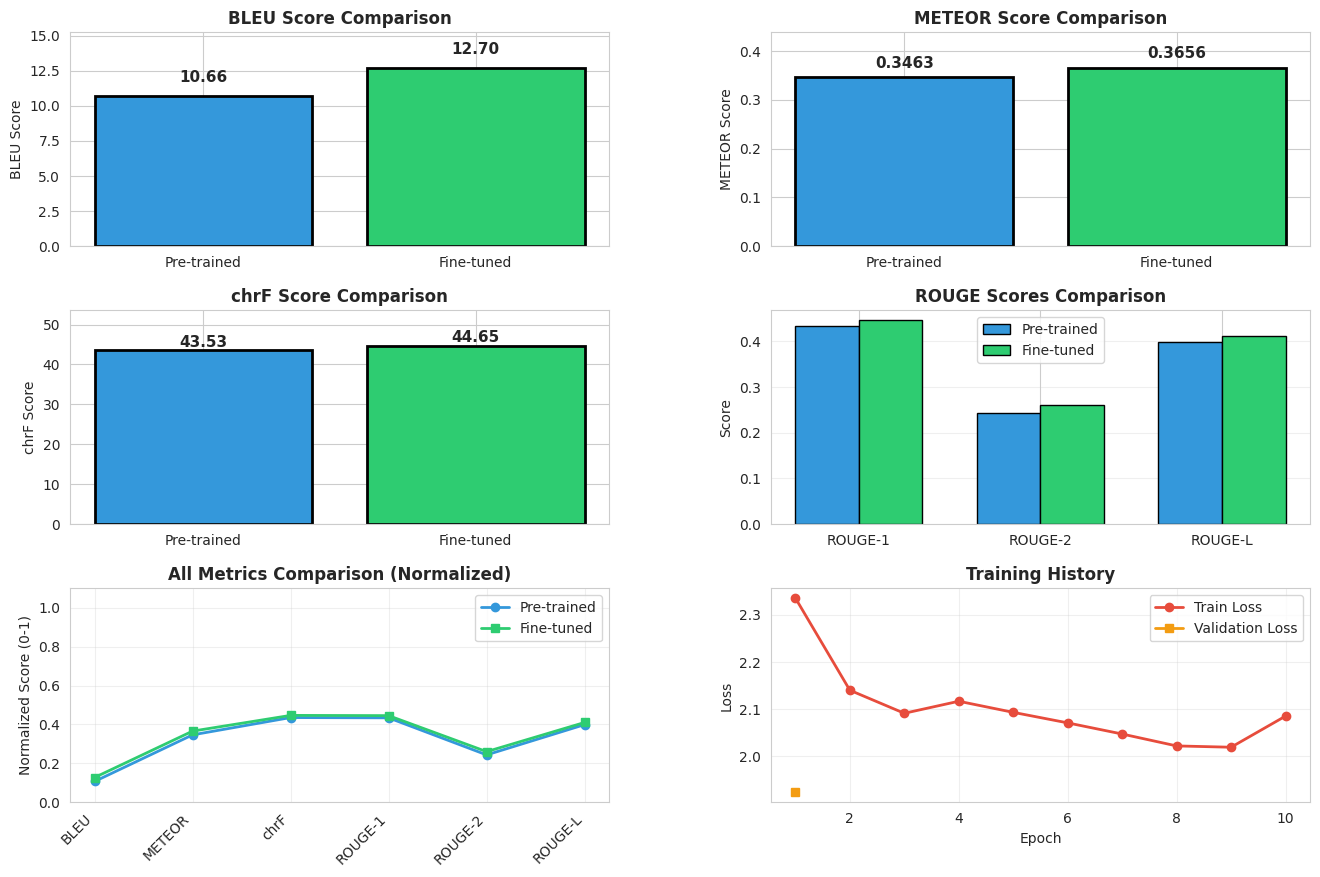


Saving results...

NLLB EXPERIMENT COMPLETED!

Files saved:
  - nllb_results.png (comprehensive visualization with all metrics)
  - nllb_test_results.csv (detailed translations)
  - nllb_summary.csv (all metrics summary)
  - Model saved in: ./nllb-fr-tr-finetuned/final_model/

✓ Training was FASTER due to:
  - Reduced dataset (1/4 train, 1/4 val, 1/2 test)
  - Only 2 epochs
  - Larger batch size (16)
  - Gradient accumulation (2 steps)
  - Higher learning rate (3e-5)

✓ Ready to proceed with the next model!


In [22]:
print("STEP 9: VISUALIZING RESULTS")
print("="*60)

# Create comparison plot with multiple metrics
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. BLEU Score comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Pre-trained', 'Fine-tuned']
bleu_scores = [pretrained_bleu['score'], finetuned_bleu['score']]
colors = ['#3498db', '#2ecc71']
ax1.bar(models, bleu_scores, color=colors, edgecolor='black', linewidth=2)
ax1.set_title('BLEU Score Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('BLEU Score')
ax1.set_ylim(0, max(bleu_scores) * 1.2)
for i, v in enumerate(bleu_scores):
    ax1.text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# 2. METEOR Score comparison
ax2 = fig.add_subplot(gs[0, 1])
meteor_scores = [pretrained_meteor['meteor'], finetuned_meteor['meteor']]
ax2.bar(models, meteor_scores, color=colors, edgecolor='black', linewidth=2)
ax2.set_title('METEOR Score Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('METEOR Score')
ax2.set_ylim(0, max(meteor_scores) * 1.2)
for i, v in enumerate(meteor_scores):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)

# 3. chrF Score comparison
ax3 = fig.add_subplot(gs[1, 0])
chrf_scores = [pretrained_chrf['score'], finetuned_chrf['score']]
ax3.bar(models, chrf_scores, color=colors, edgecolor='black', linewidth=2)
ax3.set_title('chrF Score Comparison', fontsize=12, fontweight='bold')
ax3.set_ylabel('chrF Score')
ax3.set_ylim(0, max(chrf_scores) * 1.2)
for i, v in enumerate(chrf_scores):
    ax3.text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# 4. ROUGE Scores comparison
ax4 = fig.add_subplot(gs[1, 1])
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
pretrained_rouge_scores = [pretrained_rouge['rouge1'], pretrained_rouge['rouge2'], pretrained_rouge['rougeL']]
finetuned_rouge_scores = [finetuned_rouge['rouge1'], finetuned_rouge['rouge2'], finetuned_rouge['rougeL']]
x = np.arange(len(rouge_metrics))
width = 0.35
ax4.bar(x - width/2, pretrained_rouge_scores, width, label='Pre-trained', color='#3498db', edgecolor='black')
ax4.bar(x + width/2, finetuned_rouge_scores, width, label='Fine-tuned', color='#2ecc71', edgecolor='black')
ax4.set_title('ROUGE Scores Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score')
ax4.set_xticks(x)
ax4.set_xticklabels(rouge_metrics)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. All metrics comparison (normalized)
ax5 = fig.add_subplot(gs[2, 0])
all_metrics = ['BLEU', 'METEOR', 'chrF', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
# Normalize scores to 0-1 range for better visualization
pretrained_all = [
    pretrained_bleu['score']/100,
    pretrained_meteor['meteor'],
    pretrained_chrf['score']/100,
    pretrained_rouge['rouge1'],
    pretrained_rouge['rouge2'],
    pretrained_rouge['rougeL']
]
finetuned_all = [
    finetuned_bleu['score']/100,
    finetuned_meteor['meteor'],
    finetuned_chrf['score']/100,
    finetuned_rouge['rouge1'],
    finetuned_rouge['rouge2'],
    finetuned_rouge['rougeL']
]
x_pos = np.arange(len(all_metrics))
ax5.plot(x_pos, pretrained_all, marker='o', linewidth=2, label='Pre-trained', color='#3498db')
ax5.plot(x_pos, finetuned_all, marker='s', linewidth=2, label='Fine-tuned', color='#2ecc71')
ax5.set_title('All Metrics Comparison (Normalized)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Normalized Score (0-1)')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(all_metrics, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim(0, 1.1)

# 6. Training history
ax6 = fig.add_subplot(gs[2, 1])
if hasattr(trainer.state, 'log_history'):
    train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
    eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

    epochs = range(1, len(train_losses) + 1)
    ax6.plot(epochs, train_losses[:len(epochs)], marker='o', label='Train Loss', color='#e74c3c', linewidth=2)
    if eval_losses:
        eval_epochs = range(1, len(eval_losses) + 1)
        ax6.plot(eval_epochs, eval_losses, marker='s', label='Validation Loss', color='#f39c12', linewidth=2)
    ax6.set_title('Training History', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Loss')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.savefig('nllb_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results to CSV
print("\nSaving results...")
test_subset.to_csv('nllb_test_results.csv', index=False)

# Save summary
summary = {
    'Model': 'NLLB',
    'Pre-trained_BLEU': pretrained_bleu['score'],
    'Fine-tuned_BLEU': finetuned_bleu['score'],
    'BLEU_Improvement': finetuned_bleu['score'] - pretrained_bleu['score'],
    'Pre-trained_METEOR': pretrained_meteor['meteor'],
    'Fine-tuned_METEOR': finetuned_meteor['meteor'],
    'METEOR_Improvement': finetuned_meteor['meteor'] - pretrained_meteor['meteor'],
    'Pre-trained_chrF': pretrained_chrf['score'],
    'Fine-tuned_chrF': finetuned_chrf['score'],
    'chrF_Improvement': finetuned_chrf['score'] - pretrained_chrf['score'],
    'Pre-trained_ROUGE1': pretrained_rouge['rouge1'],
    'Fine-tuned_ROUGE1': finetuned_rouge['rouge1'],
    'ROUGE1_Improvement': finetuned_rouge['rouge1'] - pretrained_rouge['rouge1'],
    'Pre-trained_ROUGE2': pretrained_rouge['rouge2'],
    'Fine-tuned_ROUGE2': finetuned_rouge['rouge2'],
    'ROUGE2_Improvement': finetuned_rouge['rouge2'] - pretrained_rouge['rouge2'],
    'Pre-trained_ROUGEL': pretrained_rouge['rougeL'],
    'Fine-tuned_ROUGEL': finetuned_rouge['rougeL'],
    'ROUGEL_Improvement': finetuned_rouge['rougeL'] - pretrained_rouge['rougeL'],
    'Train_Samples': len(train_df),
    'Val_Samples': len(val_df),
    'Test_Samples': len(test_subset),
    'Epochs': 2
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('nllb_summary.csv', index=False)

print("\n" + "="*60)
print("NLLB EXPERIMENT COMPLETED!")
print("="*60)
print(f"\nFiles saved:")
print(f"  - nllb_results.png (comprehensive visualization with all metrics)")
print(f"  - nllb_test_results.csv (detailed translations)")
print(f"  - nllb_summary.csv (all metrics summary)")
print(f"  - Model saved in: ./nllb-fr-tr-finetuned/final_model/")
print("\n✓ Training was FASTER due to:")
print("  - Reduced dataset (1/4 train, 1/4 val, 1/2 test)")
print("  - Only 2 epochs")
print("  - Larger batch size (16)")
print("  - Gradient accumulation (2 steps)")
print("  - Higher learning rate (3e-5)")
print("\n✓ Ready to proceed with the next model!")